In [ ]:
import os
import random
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# ===================== Configuration =====================
IMG_SIZE = 512  
SIZE = (IMG_SIZE, IMG_SIZE)
NUM_CLASSES = 5
BATCH_SIZE = 16  
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 15

# ===================== Define Local Paths =====================
# Update the local directory paths
work_dir = '/Datasets/cassava-leaf-disease-classification/'
train_path = os.path.join(work_dir, 'train_images')
TEST_DIR = os.path.join(work_dir, 'test_images/')
# Directory to store outputs
output_dir = '/Results'
os.makedirs(output_dir, exist_ok=True)

# ===================== Setup =====================
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Enable mixed precision for faster training (if training were needed)
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# Set seed for reproducibility
def seed_everything(seed=21):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

seed_everything()
warnings.filterwarnings('ignore')


Num GPUs Available: 1


In [2]:

# ===================== Load Dataset =====================
data = pd.read_csv(os.path.join(work_dir, 'train.csv'))

with open(os.path.join(work_dir, 'label_num_to_disease_map.json')) as f:
    real_labels = json.load(f)
    real_labels = {int(k): v for k, v in real_labels.items()}

# Map label numbers to disease names
data['class_name'] = data['label'].map(real_labels)
train_df, test_df = train_test_split(data, test_size=0.1, random_state=42, stratify=data['class_name'])


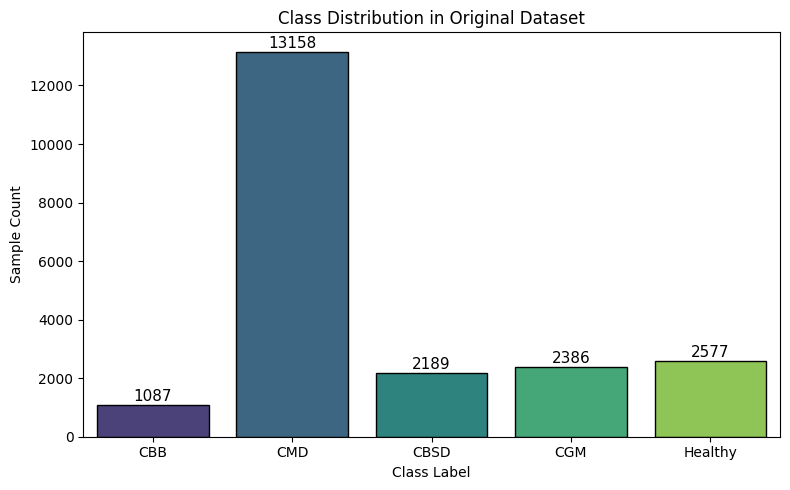

In [3]:

# ===================== Visualize Class Distribution =====================
label_map = {
    0: 'CBB',
    1: 'CBSD',
    2: 'CGM',
    3: 'CMD',
    4: 'Healthy'
}
data['short_label'] = data['label'].map(label_map)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='short_label', data=data, palette='viridis', edgecolor='black')
plt.title("Class Distribution in Original Dataset")
plt.xlabel("Class Label")
plt.ylabel("Sample Count")
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center', fontsize=11, xytext=(0, 6), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_distribution.png"))
plt.show()


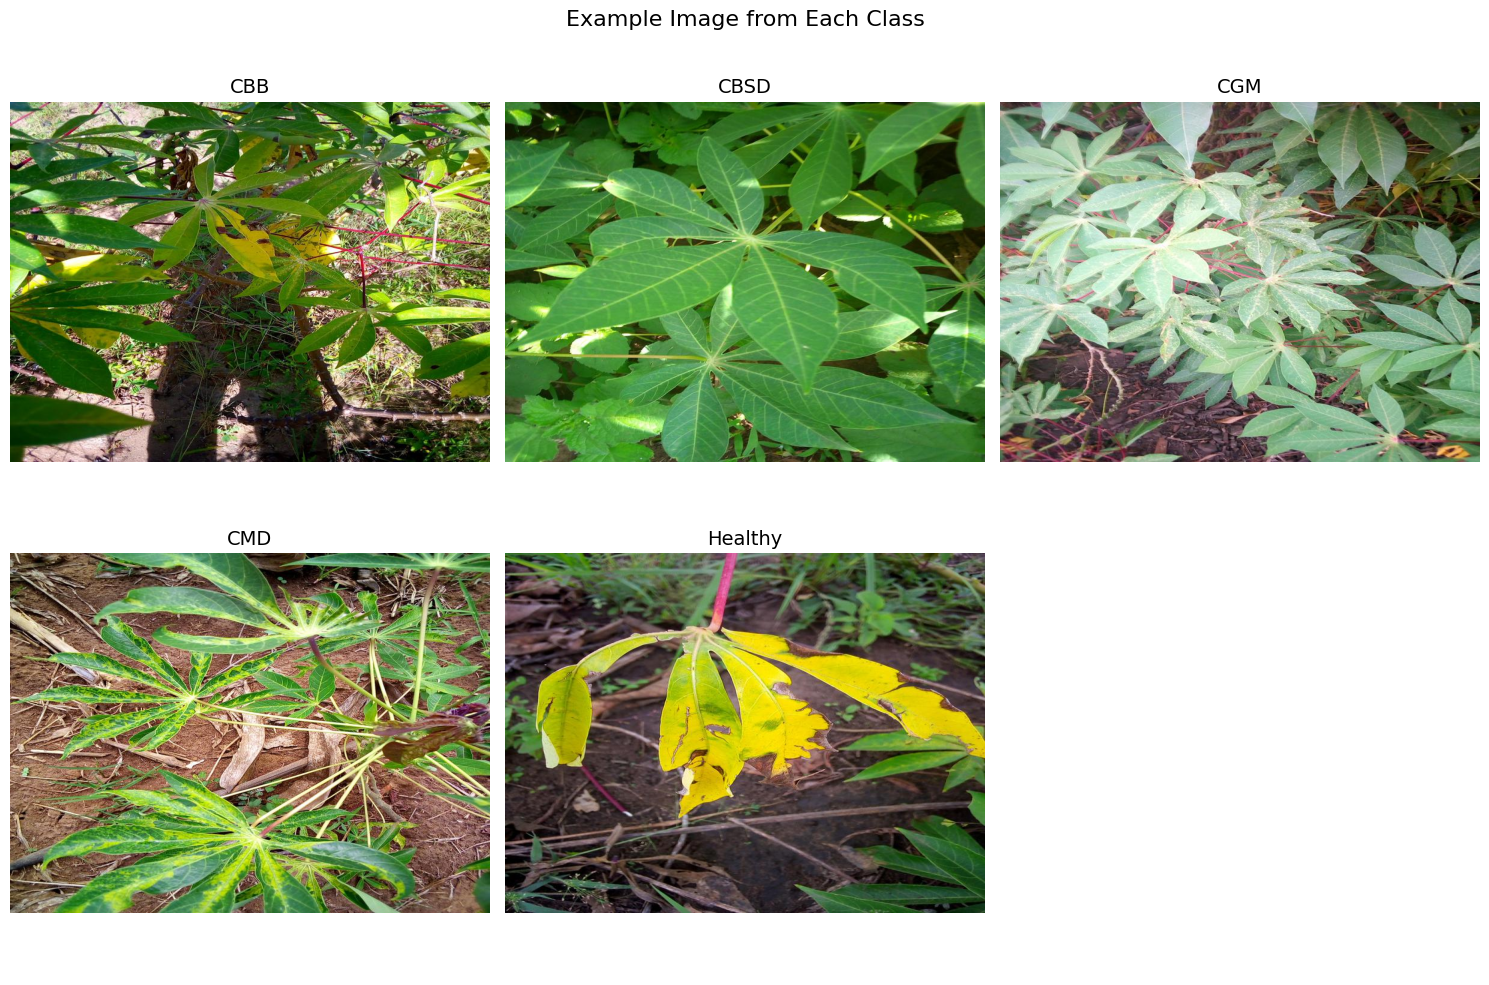

In [4]:

# ===================== Sample Images per Class =====================
import matplotlib.image as mpimg
sample_dir = train_path
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
classes = sorted(data['label'].unique())

for i, label in enumerate(classes):
    img_name = data[data['label'] == label].iloc[0]['image_id']
    img_path = os.path.join(sample_dir, img_name)
    img = mpimg.imread(img_path)
    row, col = divmod(i, 3)
    axes[row][col].imshow(img)
    axes[row][col].set_title(f"{label_map[label]}", fontsize=14)
    axes[row][col].axis('off')
for j in range(len(classes), 6):
    row, col = divmod(j, 3)
    axes[row][col].axis('off')
plt.suptitle("Example Image from Each Class", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "class_samples.png"))
plt.show()


In [9]:

# ===================== Data Generators =====================
# Data augmentation for training (kept for demonstration purposes)
datagen_train = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

train_generator = datagen_train.flow_from_dataframe(
    train_df,
    directory=train_path,
    x_col='image_id',
    y_col='class_name',
    subset='training',
    target_size=SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    batch_size=BATCH_SIZE
)

validation_datagen = ImageDataGenerator(
    validation_split=0.2,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

validation_generator = validation_datagen.flow_from_dataframe(
    train_df,
    directory=train_path,
    x_col='image_id',
    y_col='class_name',
    subset='validation',
    target_size=SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    batch_size=BATCH_SIZE
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory=train_path,
    x_col='image_id',
    y_col='class_name',
    target_size=SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42,
    batch_size=BATCH_SIZE
)



Found 15406 validated image filenames belonging to 5 classes.
Found 3851 validated image filenames belonging to 5 classes.
Found 2140 validated image filenames belonging to 5 classes.


Found 1 validated image filenames belonging to 1 classes.


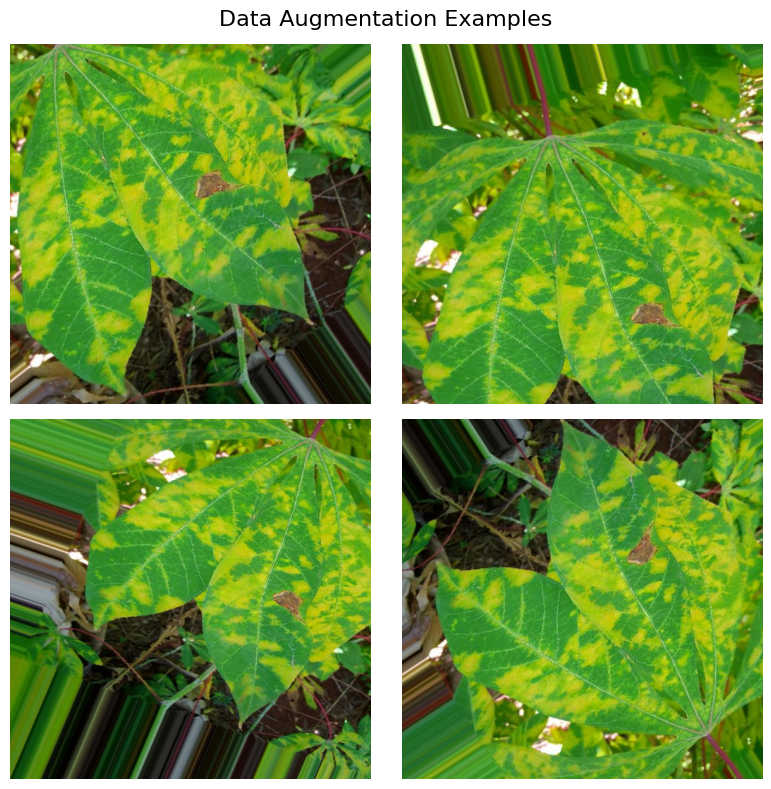


Found 1 validated image filenames belonging to 1 classes in augmentation preview.


In [10]:

# ===================== Data Augmentation Visualization =====================
sample_aug = train_df.iloc[[0]].copy()
sample_aug['class_name'] = sample_aug['label'].map(real_labels)
preview_gen = datagen_train.flow_from_dataframe(
    sample_aug,
    directory=train_path,
    x_col='image_id',
    y_col='class_name',
    target_size=SIZE,
    class_mode='categorical',
    batch_size=1
)
aug_imgs = [preview_gen[0][0][0] / 255.0 for _ in range(4)]
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
for i in range(4):
    axs.flat[i].imshow(aug_imgs[i])
    axs.flat[i].axis('off')
plt.suptitle("Data Augmentation Examples", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "augmentation_samples.png"))
plt.show()
print("\nFound {} validated image filenames belonging to {} classes in augmentation preview.".format(
    preview_gen.n, 1))


In [11]:

# ===================== Compute Class Weights =====================
# Compute class weights to counter class imbalance
class_counts = train_df['label'].value_counts().sort_index()
total_samples = len(train_df)
class_weights = {i: total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)}
print("Class Weights:", class_weights)

# ===================== Model Definition =====================
def create_model():
    model = Sequential([
        EfficientNetB3(
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            include_top=False,
            weights='imagenet'
        ),
        GlobalAveragePooling2D(),
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),  # Using L2 regularization
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return model


Class Weights: {0: 3.938036809815951, 1: 1.95502538071066, 2: 1.7930167597765363, 3: 0.3252322242864381, 4: 1.6608020698576973}


In [12]:

# ===================== Two-Stage Training =====================
# >>>>> ORIGINAL TRAINING CODE (for demonstration only) <<<<<
# Uncomment the block below if you want to train the model instead of loading a pre-trained one.
'''
# Stage 1: Train the new classifier head with the base model frozen
model_stage1 = create_model()
# Freeze base model layers
model_stage1.layers[0].trainable = False

model_stage1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False, label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('Cassava_best_model_stage1.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

history_stage1 = model_stage1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_STAGE1,
    callbacks=callbacks_stage1,
    class_weight=class_weights
)

# Stage 2: Fine-tune by unfreezing part of the base model
for layer in model_stage1.layers[0].layers[-60:]:
    layer.trainable = True

model_stage1.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False, label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_stage2 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint('Cassava_best_model_stage2.keras', save_best_only=True, monitor='val_accuracy', mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
]

history_stage2 = model_stage1.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_STAGE2,
    callbacks=callbacks_stage2,
    class_weight=class_weights
)

# Save final fine-tuned model
model_stage1.save('Cassava_model_finetuned.keras')
'''

# ===================== Load Pre-trained Model =====================
# Instead of training, load the pre-trained model for evaluation and demonstration
model = load_model(os.path.join(output_dir, 'Cassava_model_finetuned.keras'))
print("\nPre-trained model loaded successfully.")


2025-04-08 12:59:00.532565: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-04-08 12:59:00.532777: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-04-08 12:59:00.532781: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-04-08 12:59:00.532933: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-08 12:59:00.532945: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



Pre-trained model loaded successfully.


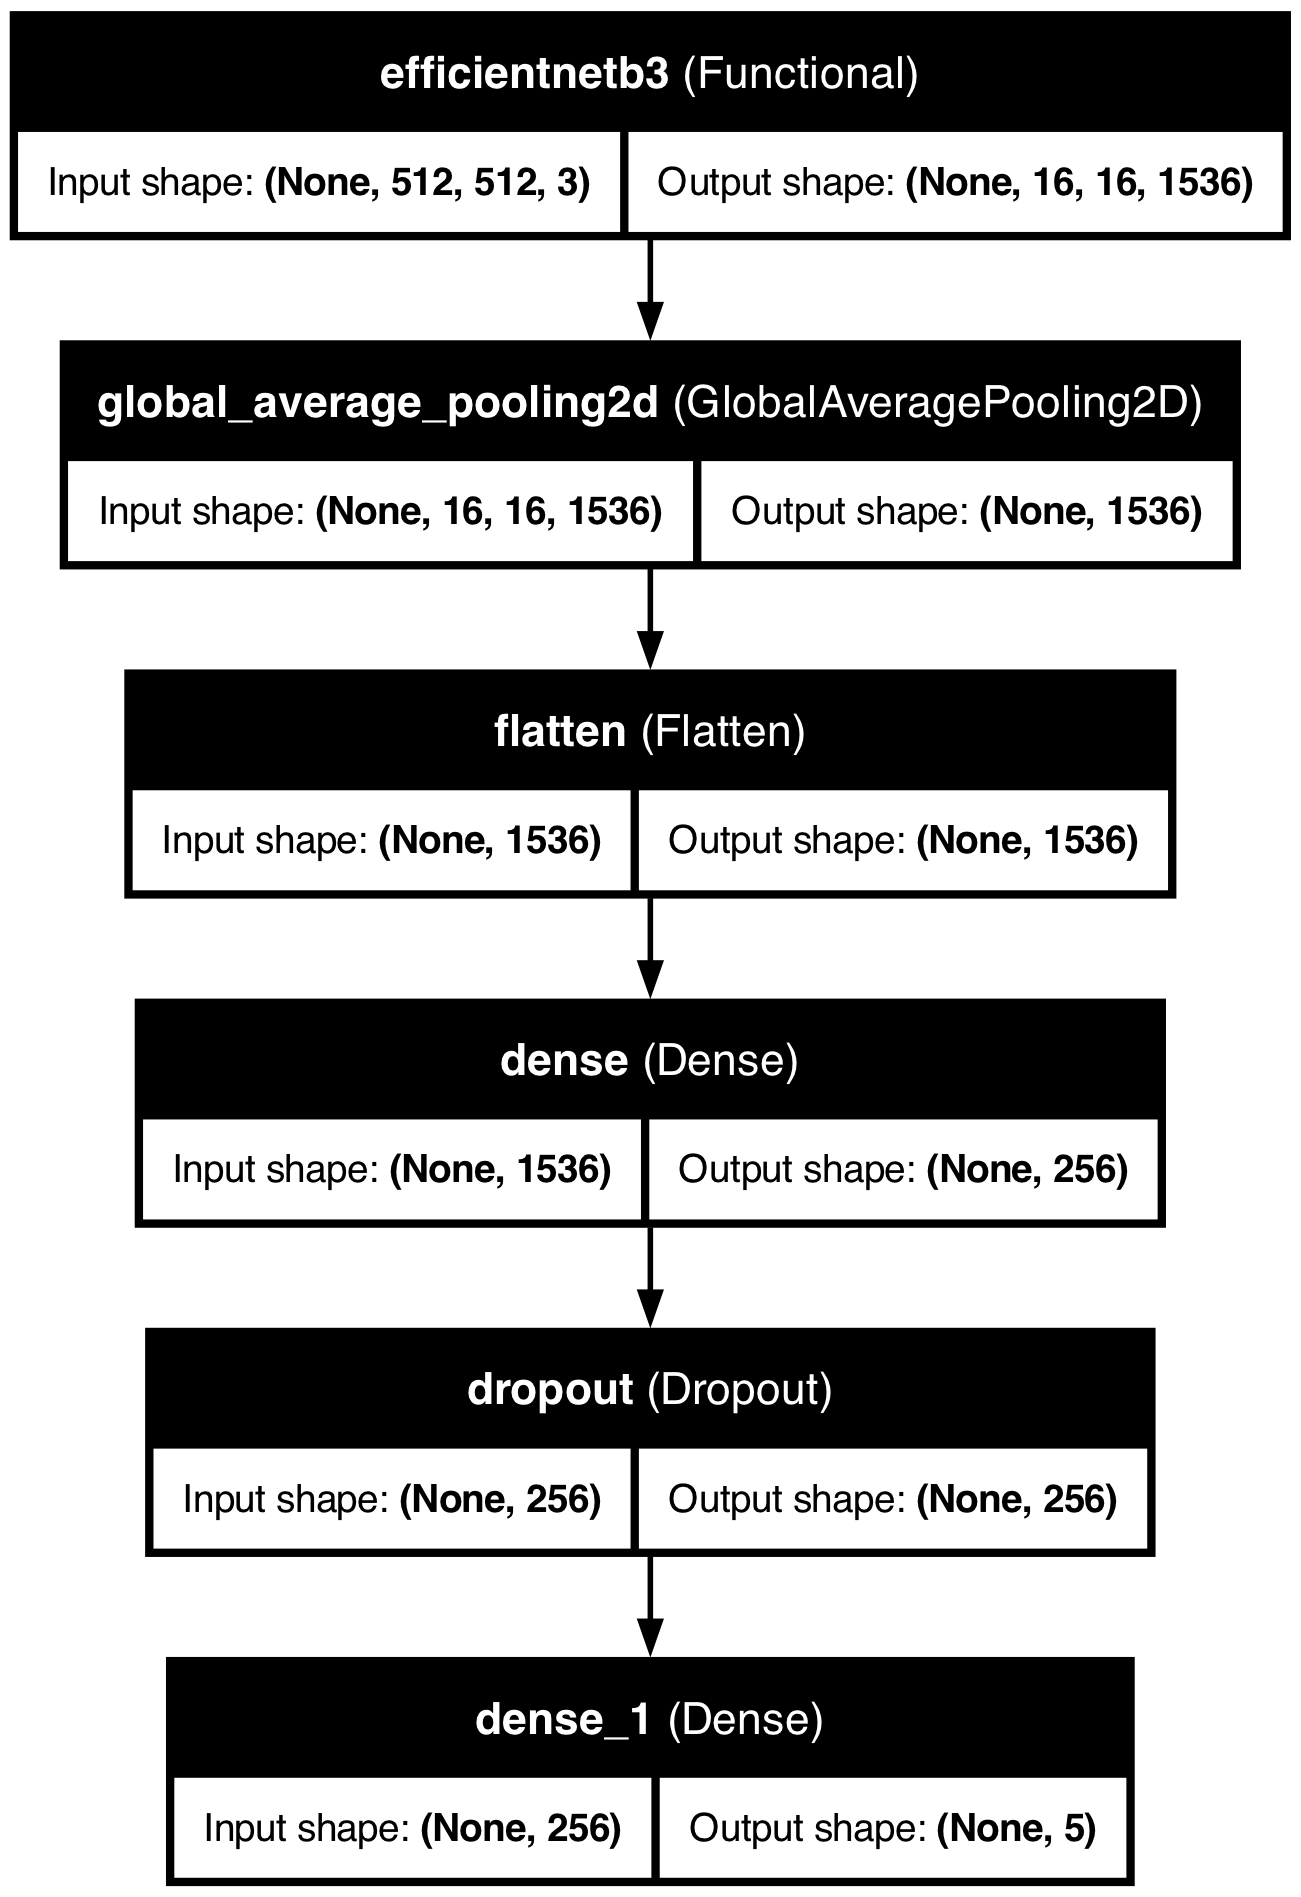

In [13]:

# ===================== Model Architecture Visualization =====================
plot_model(model, to_file=os.path.join(output_dir, "model_architecture.png"), show_shapes=True, show_layer_names=True)


2025-04-08 12:59:19.987739: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


134/134 ━━━━━━━━━━━━━━━━━━━━ 325s 2s/step - accuracy: 0.8177 - loss: 1.0983

Final model evaluation - Loss: 1.0944, Accuracy: 0.8192
134/134 ━━━━━━━━━━━━━━━━━━━━ 414s 3s/step


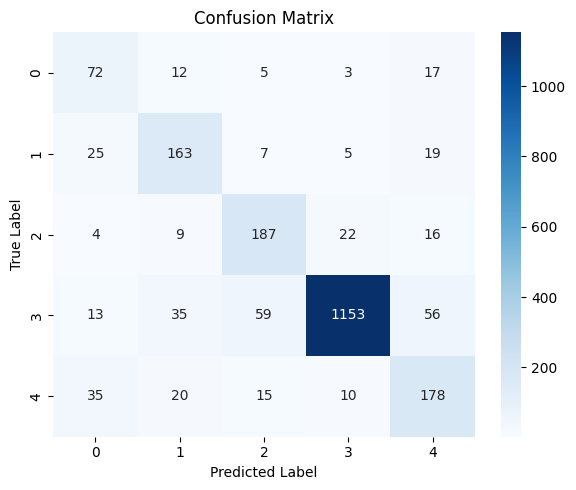


Classification Report:
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.48      0.66      0.56       109
Cassava Brown Streak Disease (CBSD)       0.68      0.74      0.71       219
         Cassava Green Mottle (CGM)       0.68      0.79      0.73       238
       Cassava Mosaic Disease (CMD)       0.97      0.88      0.92      1316
                            Healthy       0.62      0.69      0.65       258

                           accuracy                           0.82      2140
                          macro avg       0.69      0.75      0.72      2140
                       weighted avg       0.84      0.82      0.83      2140



In [14]:

# ===================== Evaluation =====================

# Evaluate the model using the test generator
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nFinal model evaluation - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

# Predict on test set and generate confusion matrix and classification report
y_true = test_df['label'].values
pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

conf_mat = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
plt.show()

print("\nClassification Report:")
target_names = [real_labels[i] for i in range(NUM_CLASSES)]
print(classification_report(y_true, y_pred, target_names=target_names))
